# Lab 1 — Anatomía de tu parcela
**Módulo 5 · Digitalización del Campo: Datos con Satélites** · Clase 1

En este laboratorio vas a **conocer la parcela del caso integrador** y obtener su **primera imagen Sentinel-2 real**. Es el primer commit de tu proyecto, que crecerá clase a clase hasta una recomendación accionable.

### Qué vas a hacer
1. Definir el **área de interés (AOI)** de la parcela.
2. **Inventariar** cuántas escenas Sentinel-2 L2A con poca nube hay en la campaña (acceso anónimo, sin credenciales).
3. **Cargar y visualizar** una escena reciente en color natural (RGB) usando **acceso real**.
4. Generar tu **`data_card.md`** con los metadatos y la calidad del dato.

### Rutas (elige según tu perfil)
- **Ruta A (guiada):** ejecuta las celdas tal cual; lee los comentarios; responde las preguntas del final.
- **Ruta B (ingeniería):** además, sustituye el bbox por la geometría real (GeoJSON de SIGPAC), cambia la ventana temporal y comenta el código.

> **Clase 1:** la imagen **localiza y prioriza**, no diagnostica. Lo que veas hoy es el punto de partida; la interpretación agronómica se construye en las clases siguientes.


## 0. Entorno

Si trabajas en local, crea el entorno con `environment.yml` (ver `README.md`). Si trabajas en Google Colab, ejecuta la celda de instalación.


In [49]:
# --- Instalación  ---
%pip install -q earthengine-api geemap pystac-client rioxarray xarray matplotlib geopandas openeo

Note: you may need to restart the kernel to use updated packages.


In [50]:
import sys
print("Python:", sys.version.split()[0])

Python: 3.12.13


In [51]:
import json
from datetime import date
import matplotlib.pyplot as plt

# === Parámetros del caso integrador (Castilla y León - trigo - campaña 2024-25) ===
# AOI por defecto: bbox cerca de Valladolid. Ruta B: reemplaza por tu GeoJSON real (SIGPAC).

#BBOX = [-60.720, -33.684, -60.713, -33.679]   # [oeste, sur, este, norte] en EPSG:4326
FECHA_INICIO = "2024-12-03"
FECHA_FIN     = "2025-04-25"
MAX_NUBES     = 30                      # % de cobertura de nube máxima

# Geometría GeoJSON (Ruta B): si tienes data/parcela.geojson, cárgala aquí.
import geopandas as gpd; aoi = gpd.read_file("data/parcela.geojson"); BBOX = list(aoi.total_bounds)

centro = [(BBOX[1]+BBOX[3])/2, (BBOX[0]+BBOX[2])/2]  # [lat, lon]
print("AOI bbox:", BBOX)
print("Centro [lat, lon]:", centro)
print("Ventana temporal:", FECHA_INICIO, "->", FECHA_FIN, "| nubes <", MAX_NUBES, "%")


AOI bbox: [np.float64(-60.723428), np.float64(-33.68732), np.float64(-60.710277), np.float64(-33.676992)]
Centro [lat, lon]: [np.float64(-33.682156), np.float64(-60.7168525)]
Ventana temporal: 2024-12-03 -> 2025-04-25 | nubes < 30 %


## 1. Inventario de escenas (acceso anónimo — Copernicus Data Space STAC)

Antes de descargar nada, preguntamos al catálogo **cuántas escenas Sentinel-2 L2A** con poca nube existen para tu parcela en la campaña. Esto **no requiere credenciales**. (Es la verificación que pide el checklist del caso integrador: ≥ 30 escenas con < 30 % de nubes.)


In [52]:
from pystac_client import Client

# Endpoint STAC del Copernicus Data Space Ecosystem (CDSE).
STAC_URL = "https://stac.dataspace.copernicus.eu/v1"

def inventariar_escenas(bbox, inicio, fin, max_nubes=30):
    cat = Client.open(STAC_URL)
    search = cat.search(
        collections=["sentinel-2-l2a"],   # id de colección en minúscula en el catálogo v1
        bbox=bbox,
        datetime=f"{inicio}/{fin}",
    )
    items = list(search.items())
    # Filtro de nubes y nivel L2A en cliente (los nombres de propiedad pueden variar
    # entre versiones del catálogo; por eso filtramos de forma defensiva).
    def nubes(it):
        p = it.properties
        for k in ("eo:cloud_cover", "cloudCover", "s2:cloudy_pixel_percentage"):
            if k in p and p[k] is not None:
                return float(p[k])
        return None
    def es_l2a(it):
        s = (it.id + " " + str(it.properties.get("productType", ""))).upper()
        return "L2A" in s or "MSIL2A" in s
    l2a = [it for it in items if es_l2a(it)]
    poco_nube = [it for it in l2a if (nubes(it) is None or nubes(it) <= max_nubes)]
    return items, l2a, poco_nube, nubes

try:
    todos, l2a, utiles, nubes = inventariar_escenas(BBOX, FECHA_INICIO, FECHA_FIN, MAX_NUBES)
    print(f"Escenas totales en la ventana: {len(todos)}")
    print(f"  de ellas L2A: {len(l2a)}")
    print(f"  L2A con nube <= {MAX_NUBES}%: {len(utiles)}")
    print("\n¿Cumple el criterio del caso (>= 30 escenas útiles)?", "SÍ ✅" if len(utiles) >= 30 else "Revisar ⚠️")
    print("\nPrimeras 5 escenas útiles (id | fecha | %nube):")
    for it in sorted(utiles, key=lambda x: x.datetime)[:5]:
        print(" ", it.id[:45], "|", str(it.datetime.date()), "|", nubes(it))
except Exception as e:
    print("No se pudo consultar el STAC ahora mismo:", type(e).__name__, e)
    print("Revisa conectividad o el endpoint. Puedes continuar con la Opción de visualización (sección 2).")


Escenas totales en la ventana: 34
  de ellas L2A: 34
  L2A con nube <= 30%: 18

¿Cumple el criterio del caso (>= 30 escenas útiles)? Revisar ⚠️

Primeras 5 escenas útiles (id | fecha | %nube):
  S2B_MSIL2A_20241211T135709_N0511_R067_T20HQH_ | 2024-12-11 | 0.81
  S2A_MSIL2A_20241216T135701_N0511_R067_T20HQH_ | 2024-12-16 | 0.39
  S2C_MSIL2A_20241216T135731_N9905_R067_T20HQH_ | 2024-12-16 | 0.43
  S2C_MSIL2A_20241216T135731_N0511_R067_T20HQH_ | 2024-12-16 | 0.42
  S2A_MSIL2A_20241226T135701_N0511_R067_T20HQH_ | 2024-12-26 | 16.64


## 2. Cargar y visualizar una escena (ACCESO REAL)

### Earth-search (AWS)

Lee Sentinel-2 L2A del **bucket público de AWS** (`sentinel-cogs`) a través del catálogo STAC de Element84.

Solo usa `pystac-client` + `rioxarray`, que ya están en el entorno del curso.


In [53]:
from pystac_client import Client
import rioxarray as rxr
from rasterio.warp import transform_bounds

# Catálogo STAC público de Element84 sobre el bucket abierto de AWS (sentinel-cogs).
EARTH_SEARCH = "https://earth-search.aws.element84.com/v1"

def visualizar_earthsearch():
    """earth-search (AWS)

    Lee Sentinel-2 L2A directamente del bucket público `sentinel-cogs`.
    Elige la escena MENOS nubosa de la campaña y dibuja su
    composición true-color (asset 'visual', RGB 8-bit a 10 m).
    """
    cat = Client.open(EARTH_SEARCH)
    search = cat.search(
        collections=["sentinel-2-l2a"],
        bbox=BBOX,
        datetime=f"{FECHA_INICIO}/{FECHA_FIN}",
        query={"eo:cloud_cover": {"lt": MAX_NUBES}},
    )
    items = sorted(search.items(), key=lambda it: it.properties.get("eo:cloud_cover", 100))
    if not items:
        print(f"No hay escenas con nube < {MAX_NUBES}%. Sube MAX_NUBES o amplía las fechas.")
        return None

    it = items[0]
    print("Escena menos nubosa:", it.id)
    print("Fecha:", str(it.datetime.date()), "| nube:", it.properties.get("eo:cloud_cover"), "%")

    # Asset 'visual' = imagen true-color ya compuesta (RGB, uint8). El más simple para ver.
    href = it.assets["visual"].href
    if href.startswith("s3://"):
        href = href.replace("s3://sentinel-cogs/",
                            "https://sentinel-cogs.s3.us-west-2.amazonaws.com/")

    da = rxr.open_rasterio(href)                      # lazy, vía /vsicurl (HTTP remoto)
    # El COG está en UTM; reproyectamos el bbox (EPSG:4326) al CRS del raster y recortamos.
    left, bottom, right, top = transform_bounds("EPSG:4326", da.rio.crs, *BBOX)
    da = da.rio.clip_box(minx=left, miny=bottom, maxx=right, maxy=top)

    arr = da.values.transpose(1, 2, 0)               # (bandas,y,x) -> (y,x,bandas), 0-255
    plt.figure(figsize=(6, 6)); plt.imshow(arr)
    plt.title(f"Parcela — S2 RGB (earth-search) {it.datetime.date()}"); plt.axis("off"); plt.show()
    return da

#da = visualizar_earthsearch()


#### Galería: las 10 escenas menos nubosas (evolución temporal)

Una sola imagen localiza; **varias fechas cuentan una historia**. La celda siguiente pinta las 10 escenas más limpias de la campaña en una rejilla. Pon `orden="fecha"` para verlas en orden cronológico y leer la **fenología** del trigo (siembra → encañado → pico de verdor en mayo → senescencia → cosecha en julio).

> Misma vía gratuita (earth-search), sin créditos ni login. Cada imagen se lee bajo demanda, así que tardará unos segundos.


Mostrando 10 escenas (de 16 con nube < 30%).


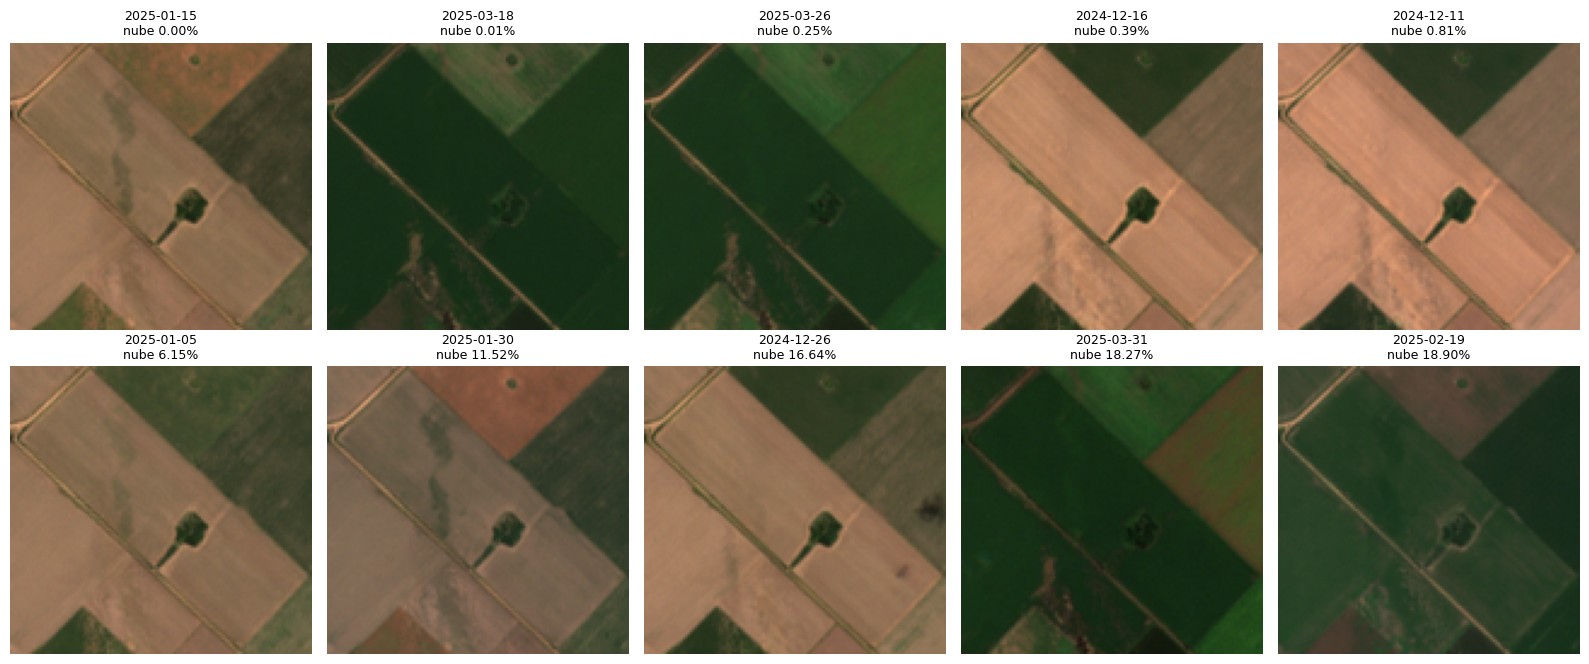

In [54]:
def galeria_earthsearch(n=10, orden="nube"):
    """Muestra las N escenas menos nubosas de la campaña en una rejilla (earth-search).

    Misma vía, pero pinta varias fechas a la vez para ver la EVOLUCIÓN temporal de la parcela.
      n     : nº de escenas a mostrar (por defecto 10).
      orden : 'nube' = las menos nubosas; 'fecha' = orden cronológico (las menos
              nubosas, pero ordenadas por fecha para leer la fenología del cultivo).
    """
    cat = Client.open(EARTH_SEARCH)
    search = cat.search(
        collections=["sentinel-2-l2a"],
        bbox=BBOX,
        datetime=f"{FECHA_INICIO}/{FECHA_FIN}",
        query={"eo:cloud_cover": {"lt": MAX_NUBES}},
    )
    items = sorted(search.items(), key=lambda it: it.properties.get("eo:cloud_cover", 100))
    if not items:
        print(f"No hay escenas con nube < {MAX_NUBES}%. Sube MAX_NUBES o amplía fechas.")
        return None

    seleccion = items[:n]                       # las n menos nubosas
    if orden == "fecha":
        seleccion = sorted(seleccion, key=lambda it: it.datetime)
    print(f"Mostrando {len(seleccion)} escenas (de {len(items)} con nube < {MAX_NUBES}%).")

    # Rejilla: ~5 columnas
    ncol = min(5, len(seleccion))
    nfil = (len(seleccion) + ncol - 1) // ncol
    fig, axes = plt.subplots(nfil, ncol, figsize=(3.2 * ncol, 3.4 * nfil))
    axes = axes.ravel() if hasattr(axes, "ravel") else [axes]

    left = bottom = right = top = None
    for ax, it in zip(axes, seleccion):
        href = it.assets["visual"].href
        if href.startswith("s3://"):
            href = href.replace("s3://sentinel-cogs/",
                                "https://sentinel-cogs.s3.us-west-2.amazonaws.com/")
        da = rxr.open_rasterio(href)
        if left is None:                         # reproyecta el bbox una sola vez por CRS
            left, bottom, right, top = transform_bounds("EPSG:4326", da.rio.crs, *BBOX)
        da = da.rio.clip_box(minx=left, miny=bottom, maxx=right, maxy=top)
        ax.imshow(da.values.transpose(1, 2, 0))
        nube = it.properties.get("eo:cloud_cover", 0)
        ax.set_title(f"{it.datetime.date()}\nnube {nube:.2f}%", fontsize=9)
        ax.axis("off")

    for ax in axes[len(seleccion):]:             # apaga ejes sobrantes
        ax.axis("off")
    plt.tight_layout(); plt.show()
    return seleccion

# galeria_earthsearch(10)                  # <- 10 menos nubosas
# galeria_earthsearch(10, orden="fecha")   # <- 10 menos nubosas, en orden cronológico
escenas = galeria_earthsearch(10)

## 3. Tu `data_card.md` (entrega del Lab 1)

La *data card* documenta de dónde viene el dato y su calidad. Es una práctica de **gobierno del dato** (Clase 1): todo dato que entra a un pipeline se documenta. Completa los campos con lo que viste arriba.


In [ ]:
data_card = f"""# Data card — Parcela del caso integrador

## Identidad
- Nombre:Parcela caso integrador
- País / Región: Partido de Pergaminos, Provincia de Buenos Aires, Argentina
- Cultivo: Soja de segunda (Post trigo)
- Superficie aprox. (ha): 100 ha
- AOI (bbox EPSG:4326): {BBOX}

## Fuente del dato
- Misión: Sentinel-2 (MSI)
- Nivel de procesado: L2A (BOA + máscara SCL)
- Proveedor: STAC público de Copernicus Data Space Element84 (AWS)
- Ventana temporal: {FECHA_INICIO} a {FECHA_FIN}

## Calidad
- Filtro de nubes: <= {MAX_NUBES}%
- Nº escenas útiles encontradas: 18
- Escena visualizada (fecha): desde 03/12/2024 al 29/04/2025
- Resolución espacial usada: 10 m (B2,B3,B4,B8)

## Dimensiones de calidad (completar 1-2 frases cada una)
- Completitud: Serie de 18 escenas de Sentinel-2 L2A con cobertura de nubes inferior a 30%.
- Exactitud / corrección atmosférica: Se utilizó Sentinel-2 L2A, que ya incluye corrección atmosférica y máscara de nubes.
- Vigencia (recencia de la escena): Las escenas corresponden a datos de la campaña 2024-25 de soja de segunda y permiten observar la evolución del cultivo.
- Consistencia (mismo CRS, mismas bandas): Todas las escenas están en el mismo sistema de coordenadas y contienen las mismas bandas.

## Notas agronómicas esperadas (campaña soja de segunda)
- Siembra: diciembre 2024
- Pico NDVI esperado: marzo 2025
- Cosecha: abril 2025

1. ¿Cuántas escenas Sentinel-2 L2A con < 30 % de nubes hay en la campaña? ¿Cumple el criterio ≥ 30?

Se encontraron 18 escenas Sentinel-2 L2A con cobertura de nubes menor o igual al 30 %. Por lo tanto, la parcela no cumple el criterio de contar 
con al menos 30 escenas útiles. Aun así, la serie permite una primera lectura temporal del cultivo durante la campaña.

2. ¿Qué observas en el RGB? ¿Qué no puedes afirmar todavía?

En las imágenes RGB se distinguen diferencias claras entre sectores del lote y entre lotes vecinos. Se observa una evolución temporal 
compatible con una soja de segunda: tonos más claros al inicio, mayor cobertura verde durante el desarrollo vegetativo y cambios hacia el final de la campaña. 
Sin embargo, solo con RGB no se puede confirmar estrés hídrico, deficiencias nutricionales, enfermedades o problemas de rendimiento. 
Para eso será necesario calcular índices como NDVI, NDRE y NDWI, y luego contrastar con clima y observación de campo.

3. ¿Por qué documentamos una data card antes de hacer ningún análisis?

La data card permite dejar documentado el origen, cobertura, calidad y limitaciones de los datos antes de analizarlos. 
Esto mejora la trazabilidad, evita interpretar resultados sin contexto y permite reproducir el trabajo en los siguientes laboratorios.
"""

with open("data_card.md", "w") as f:
    f.write(data_card)
print("Escrito data_card.md — complétalo con tus resultados y haz tu primer commit.")
print(data_card)


Escrito data_card.md — complétalo con tus resultados y haz tu primer commit.
# Data card — Parcela del caso integrador

## Identidad
- Nombre:Parcela caso integrador
- País / Región: Partido de Pergaminos, Provincia de Buenos Aires, Argentina
- Cultivo: Soja de segunda (Post trigo)
- Superficie aprox. (ha): 100 ha
- AOI (bbox EPSG:4326): [np.float64(-60.723428), np.float64(-33.68732), np.float64(-60.710277), np.float64(-33.676992)]

## Fuente del dato
- Misión: Sentinel-2 (MSI)
- Nivel de procesado: L2A (BOA + máscara SCL)
- Proveedor: STAC público de Element84 (AWS)
- Ventana temporal: 2024-12-03 a 2025-04-25

## Calidad
- Filtro de nubes: <= 30%
- Nº escenas útiles encontradas: 16
- Escena visualizada (fecha): desde 03/12/2024 al 29/04/2025
- Resolución espacial usada: 10 m (B2,B3,B4,B8)

## Dimensiones de calidad (completar 1-2 frases cada una)
- Completitud: Serie de 16 escenas de Sentinel-2 L2A con cobertura de nubes inferior a 30%.
- Exactitud / corrección atmosférica: Se utilizó

## 4. Preguntas para entregar (Ruta A)

Responde en tu `data_card.md` o en un breve texto:

1. ¿Cuántas escenas Sentinel-2 L2A con < 30 % de nubes hay en la campaña para tu parcela? ¿Cumple el criterio (≥ 30)?
2. Mira el RGB en color natural: ¿distingues estructura dentro de la parcela (zonas más claras/oscuras)? ¿Qué **no** puedes afirmar todavía solo con esta imagen?
3. ¿Por qué documentamos una *data card* antes de hacer ningún análisis?

**Entrega:** `data_card.md` + (Ruta B) el notebook ejecutado y la geometría real. Primer commit del repo del proyecto. Fecha límite: antes de la Clase 2 (16/06).
